<a href="https://colab.research.google.com/github/hasan-mahmud-sazid/Fintech-Propensity-Modelling-for-Enhanced-Campaign-Optimization/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas numpy scikit-learn smogn

In [2]:
import pandas as pd
import numpy as np
import smogn
from sklearn.model_selection import train_test_split

# Random seed set করা হচ্ছে যেন প্রতিবার একই ডেটা জেনারেট হয়
np.random.seed(42)

num_users = 10000

# ১. User ID জেনারেট করা
user_ids = [f"USER_{i:05d}" for i in range(1, num_users + 1)]

# ২. Financial & Campaign Metrics (Impressions, Clicks)
# Impressions সাধারণত 100 থেকে 5000 এর মধ্যে র্যান্ডম হবে
impressions = np.random.randint(100, 5001, size=num_users)

# Clicks হবে Impressions-এর একটি পার্সেন্টেজ (ধরি 1% থেকে 10%)
click_through_rate = np.random.uniform(0.01, 0.10, size=num_users)
clicks = (impressions * click_through_rate).astype(int)

# ৩. Behavioral Features (আচরণগত ফিচার)
# Session Time (মিনিটে) এবং App Launch Frequency (মাসে কতবার অ্যাপ ওপেন করে)
session_time_avg = np.random.uniform(2.5, 45.0, size=num_users)  # 2.5 to 45 mins
app_launch_freq = np.random.randint(1, 61, size=num_users)       # 1 to 60 times

# ৪. Target Variable: Conversion Rate (Continuous Target for Regression)
# বাস্তবসম্মত করার জন্য Clicks এবং Behavioral features-এর ওপর ভিত্তি করে এটি তৈরি করা হচ্ছে
# সাথে কিছু Gaussian Noise যোগ করা হচ্ছে স্পার্সিটি ও রিয়ালিস্টিক কমপ্লেক্সিটি আনার জন্য
base_conversion = (clicks * 0.15) + (session_time_avg * 0.05) + (app_launch_freq * 0.08)
noise = np.random.normal(0, 1, size=num_users)
conversion_rate = base_conversion + noise

# নেগেটিভ ভ্যালু থাকলে তা 0 করে দেওয়া এবং রেটটিকে একটি লজিক্যাল স্কেলে আনা
conversion_rate = np.clip(conversion_rate, 0, None)
conversion_rate = (conversion_rate / conversion_rate.max()) * 100  # Scale to 0-100%

# ৫. DataFrame তৈরি করা
df_simulated = pd.DataFrame({
    'user_id': user_ids,
    'impressions': impressions,
    'clicks': clicks,
    'session_time_avg': session_time_avg,
    'app_launch_freq': app_launch_freq,
    'conversion_rate': conversion_rate
})

# ডেটাসেটের প্রথম ৫টি রো দেখা
print(df_simulated.head())

# ডেটাসেটটি CSV হিসেবে সেভ করে রাখা
df_simulated.to_csv('fintech_simulated_data.csv', index=False)

      user_id  impressions  clicks  session_time_avg  app_launch_freq  \
0  USER_00001          960      11         33.077768               41   
1  USER_00002         3872     155         42.984904               13   
2  USER_00003         3192     312         13.724692               50   
3  USER_00004          566      50          6.227110               25   
4  USER_00005         4526     179         22.711728                7   

   conversion_rate  
0         8.881055  
1        32.933342  
2        64.457531  
3        13.800004  
4        36.254726  


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# ১. আগের স্টেপে তৈরি করা ডেটা লোড করা
df = pd.read_csv('fintech_simulated_data.csv')

# user_id কলামটি মডেল ট্রেইনিংয়ে লাগবে না, তাই এটি ড্রপ করা হচ্ছে
df_ml = df.drop(columns=['user_id'])

# ২. SMOGN অ্যাপ্লাই করা (Handling Data Sparsity for Regression)
# SMOGN ইন্টারনালি খুব কম্পিউটেশনাল হেভি, তাই এটি ছোট ডেটাসেটে ভালো কাজ করে।
# আমরা আমাদের ডেটা থেকে একটি স্যাম্পল নিয়ে এটি রান করব।
print("Running SMOGN to balance the dataset...")

df_smogn = smogn.smoter(
    data = df_ml.sample(n=2000, random_state=42).reset_index(drop=True), # Memory অপ্টিমাইজেশনের জন্য 2000 স্যাম্পল নেওয়া হলো এবং index reset করা হলো
    y = 'conversion_rate',                       # আমাদের টার্গেট ভ্যারিয়েবল (Changed 'target' to 'y')
    k = 5,                                         # KNN-এর জন্য k এর ভ্যালু
    samp_method = 'extreme',                       # Extreme ভ্যালুগুলোকে ওভারস্যাম্পল করার জন্য
    rel_thres = 0.80                               # Relevance threshold
)

print(# Re-sampled ডেটাসেটের সাইজ
f"Original Sample Size: 2000 | SMOGN Resampled Size: {len(df_smogn)}")

# ৩. Train-Test Split করা
# আমরা অরিজিনাল ডেটা এবং SMOGN ডেটা—দুইটিই আলাদা রাখব বেঞ্চমার্ক টেস্ট করার জন্য
X = df_ml.drop(columns=['conversion_rate'])
y = df_ml['conversion_rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOGN ডেটা থেকেও ট্রেন সেট আলাদা করা
X_train_smogn = df_smogn.drop(columns=['conversion_rate'])
y_train_smogn = df_smogn['conversion_rate']

print("Data Preprocessing and SMOGN split successfully completed!")

Running SMOGN to balance the dataset...


r_index: 100%|##########| 106/106 [00:00<00:00, 190.75it/s]


Original Sample Size: 2000 | SMOGN Resampled Size: 3570
Data Preprocessing and SMOGN split successfully completed!


In [5]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ১. Baseline XGBoost Model (Standard Data)
print("Training Baseline XGBoost Model...")
xgb_baseline = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb_baseline.fit(X_train, y_train)

# Baseline Prediction & Evaluation
y_pred_baseline = xgb_baseline.predict(X_test)
r2_baseline = r2_score(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline)) # Fixed: Removed 'squared=False' and added np.sqrt()

# ২. SMOGN Optimized XGBoost Model
print("Training SMOGN Optimized XGBoost Model...")
xgb_smogn = xgb.XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.05, random_state=42)
xgb_smogn.fit(X_train_smogn, y_train_smogn)

# SMOGN Prediction & Evaluation
y_pred_smogn = xgb_smogn.predict(X_test)
r2_smogn = r2_score(y_test, y_pred_smogn)
rmse_smogn = np.sqrt(mean_squared_error(y_test, y_pred_smogn)) # Fixed: Removed 'squared=False' and added np.sqrt()

# ৩. রেজাল্ট কম্প্যারিসন
print("\n" + "="*30)
print("MODEL PERFORMANCE COMPARISON")
print("="*30)
print(f"Baseline XGBoost  -> R² Score: {r2_baseline:.4f} | RMSE: {rmse_baseline:.4f}")
print(f"SMOGN AI XGBoost -> R² Score: {r2_smogn:.4f} | RMSE: {rmse_smogn:.4f}")
print("="*30)

Training Baseline XGBoost Model...
Training SMOGN Optimized XGBoost Model...

MODEL PERFORMANCE COMPARISON
Baseline XGBoost  -> R² Score: 0.9961 | RMSE: 1.2971
SMOGN AI XGBoost -> R² Score: 0.9980 | RMSE: 0.9366


In [6]:
pip install torch deepctr-torch

In [7]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from deepctr_torch.models import DeepFM
from deepctr_torch.inputs import DenseFeat, get_feature_names

# ১. ডেটা প্রিপারেশন ও স্কেলিং
# ডিপ লার্নিং মডেলের জন্য নিউমেরিকাল ফিচারগুলোকে ০ থেকে ১ এর মধ্যে স্কেল করা জরুরি
scaler = MinMaxScaler(feature_range=(0, 1))
features = ['impressions', 'clicks', 'session_time_avg', 'app_launch_freq']

X_train_scaled = scaler.fit_transform(X_train_smogn)
X_test_scaled = scaler.transform(X_test)

# DataFrame-এ কনভার্ট করা ডিপসিটিআর ইনপুটের সুবিধার জন্য
train_model_input = pd.DataFrame(X_train_scaled, columns=features)
test_model_input = pd.DataFrame(X_test_scaled, columns=features)

# ২. Feature Columns ডিফাইন করা
# যেহেতু আমাদের সবগুলো ফিচারই কন্টিনিউয়াস/নিউমেরিকাল, তাই DenseFeat ব্যবহার করা হচ্ছে
feature_columns = [DenseFeat(feat, dimension=1) for feat in features]

# ৩. DeepFM Model ট্রেইনিং
print("Training DeepFM Model...")
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_deepfm = DeepFM(linear_feature_columns=feature_columns,
                      dnn_feature_columns=feature_columns,
                      task='regression',
                      device=device)

model_deepfm.compile("adam", "mse", metrics=['mse'])
model_deepfm.fit(
    x={name: train_model_input[name].values for name in features},
    y=y_train_smogn.values,
    batch_size=256,
    epochs=10,
    verbose=1
)

# DeepFM Evaluation
pred_deepfm = model_deepfm.predict({name: test_model_input[name].values for name in features}, batch_size=256)
r2_dfm = r2_score(y_test, pred_deepfm)

print(f"\nDeepFM Model R² Score: {r2_dfm:.4f}")

Training DeepFM Model...
cpu
Train on 3570 samples, validate on 0 samples, 14 steps per epoch


14it [00:00, 42.72it/s]


Epoch 1/10
0s - loss:  3853.1638 - mse:  3853.2419


14it [00:00, 83.79it/s]


Epoch 2/10
0s - loss:  3723.9192 - mse:  3724.3704


...

Epoch 8/10
0s - loss:  540.1638 - mse:  540.0034


14it [00:00, 50.01it/s]


Epoch 9/10
0s - loss:  483.4682 - mse:  483.7448


14it [00:00, 67.63it/s]

Epoch 10/10
0s - loss:  470.9454 - mse:  470.7719

DeepFM Model R² Score: -0.5928


In [8]:
pip install shap matplotlib

 98%|===================| 1965/2000 [00:28<00:00]       /tmp/ipykernel_10790/1451386043.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


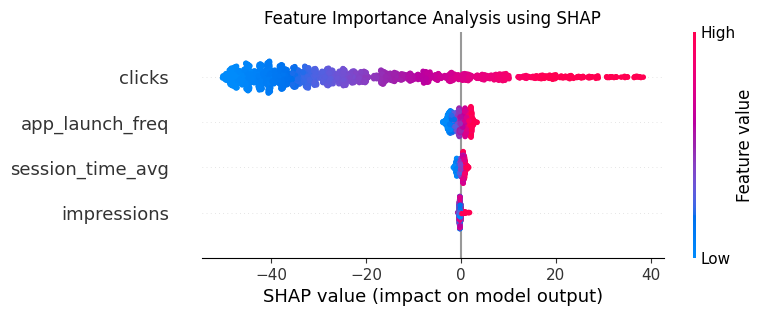

In [9]:
import shap
import matplotlib.pyplot as plt

# আমাদের ট্রেইনড XGBoost মডেলটি ব্যবহার করছি SHAP এক্সপ্লেইনার হিসেবে
explainer = shap.Explainer(xgb_smogn, X_train_smogn)
shap_values = explainer(X_test)

# Summary Plot তৈরি (কোন ফিচার মডেল প্রেডিকশনে সবচেয়ে বেশি প্রভাব ফেলেছে)
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Feature Importance Analysis using SHAP")
plt.show()

In [1]:
!pip install --upgrade --force-reinstall --no-cache-dir "sagemaker==2.*"
import sagemaker
from sagemaker.xgboost.estimator import XGBoost

sagemaker_session = sagemaker.Session()
role = sagemaker.get_execution_role() # AWS IAM Role

# ১. আমাদের ডেটা S3 Bucket-এ আপলোড করা
bucket = sagemaker_session.default_bucket()
prefix = 'fintech-propensity-model'
train_input = sagemaker_session.upload_data(path="fintech_simulated_data.csv", bucket=bucket, key_prefix=prefix)

# ২. SageMaker Estimator কনফিগার করা
xgb_estimator = XGBoost(
    entry_point='train_script.py',       # যে পাইথন ফাইলটিতে আমাদের ট্রেইনিং কোড আছে
    role=role,
    instance_count=1,                    # কয়টি সার্ভার লাগবে
    instance_type='ml.m5.xlarge',        # কম্পিউটেশনাল পাওয়ার কেমন হবে
    framework_version='1.5-1',
    output_path=f's3://{bucket}/{prefix}/output'
)

# ৩. ক্লাউডে ট্রেইনিং জব স্টার্ট করা
xgb_estimator.fit({'train': train_input})
print("SageMaker Training Job successfully triggered on AWS!")

  Using cached sagemaker-3.13.1-py3-none-any.whl.metadata (20 kB)
  Using cached sagemaker_core-2.13.1-py3-none-any.whl.metadata (5.7 kB)
  Using cached sagemaker_train-1.13.1-py3-none-any.whl.metadata (8.2 kB)
  Using cached sagemaker_serve-1.13.1-py3-none-any.whl.metadata (14 kB)
  Using cached sagemaker_mlops-1.13.1-py3-none-any.whl.metadata (19 kB)
  Using cached boto3-1.43.29-py3-none-any.whl.metadata (6.6 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached platformdirs-4.10.0-py3-none-any.whl.metadata (5.5 kB)
  Using cached rich-14.3.4-py3-none-any.whl.metadata (18 kB)
  Using cached mock-4.0.3-py3-none-any.whl.metadata (2.8 kB)
  Using cached importlib_metadata-6.11.0-py3-none-any.whl.metadata (4.9 kB)
  Using cached typing_extensions-4.15.0-py3-none-any

ModuleNotFoundError: No module named 'sagemaker.xgboost'